In [13]:
import torch
import json
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from clearml import Task, Logger

In [7]:
with open("creds.json", "r") as lines:
    creds = json.load(lines)

Task.set_credentials(
    api_host=creds["api_server"],
    web_host=creds["web_server"],
    files_host=creds["files_server"],
    key=creds["access_key"],
    secret=creds["secret_key"]
)
task = Task.init(project_name='MNIST_Project', task_name='MLP_Train') 

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# dataset = MNIST(root='./data', train=True, download=True, transform=transform)
# train_size = int(0.8 * len(dataset))
# val_size   = len(dataset) - train_size
train_dataset = MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset  = MNIST(root='./data', train=False, download=False, transform=transform)

# train_data, val_data = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,   batch_size=1000, shuffle=False)

In [4]:
class AdvancedMNISTMLPList(torch.nn.Module):
    def __init__(self):
        super(AdvancedMNISTMLPList, self).__init__()
        self.layers = torch.nn.ModuleList([
            torch.nn.Linear(28*28, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 10)
        ])
    def forward(self, x):
        x = x.view(-1, 28*28)  # раскладываем картинку в вектор
        for layer in self.layers:
            x = layer(x)
        return x


model = AdvancedMNISTMLPList()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


In [8]:
# Цикл обучения
num_epochs = 5
train_losses = []
train_accuracies = []


for epoch in range(num_epochs):
    model.train()  # перевод модели в режим обучения
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Проход по всем батчам трен.набора
    for images, labels in train_loader:
        # Прямой проход
        outputs = model(images)             # выходы - логиты [batch, 10]
        loss = criterion(outputs, labels)   # вычисляем потерю

        # Обратный проход и оптимизация
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Накопление статистики для метрик
        running_loss += loss.item()         # суммируем loss
        _, predicted = outputs.max(1)       # индекс максимальной логиты = предсказанный класс
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Средние значения по эпохе
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Выводим информацию по эпохе
    print(f'Epoch {epoch+1}/{num_epochs} — Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')
    
    # Отправляем метрики в ClearML
    Logger.current_logger().report_scalar("train", "loss", iteration=epoch, value=epoch_loss)
    Logger.current_logger().report_scalar("train", "accuracy", iteration=epoch, value=epoch_acc)

Epoch 1/5 — Loss: 0.1096, Accuracy: 96.59%
Epoch 2/5 — Loss: 0.0761, Accuracy: 97.61%
Epoch 3/5 — Loss: 0.0591, Accuracy: 98.06%
Epoch 4/5 — Loss: 0.0486, Accuracy: 98.42%
Epoch 5/5 — Loss: 0.0400, Accuracy: 98.71%


In [9]:
# Оценка на тестовом наборе и матрица ошибок
model.eval()  # режим оценки
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss / len(test_loader)
test_accuracy = 100.0 * correct / total

print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

Test Loss: 0.0834, Test Accuracy: 97.49%


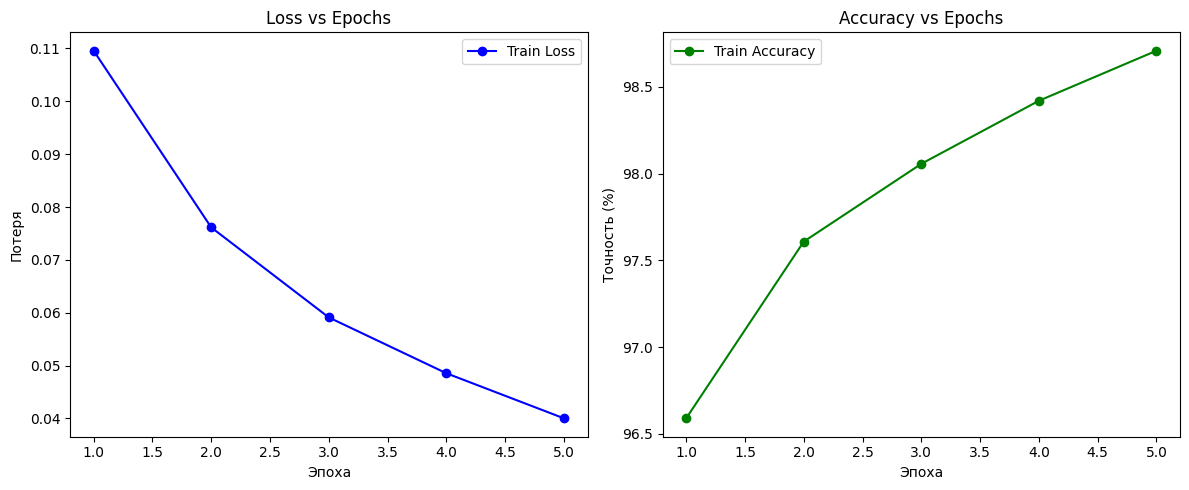

In [10]:
# Построение графиков потерь и точности
import matplotlib.pyplot as plt

epochs = range(1, num_epochs+1)
plt.figure(figsize=(12,5))  

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', color='blue', label='Train Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, marker='o', color='green', label='Train Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.legend()


plt.tight_layout()
plt.show()

In [12]:
task.get_output_log_web_page()

'https://app.clear.ml/projects/e86e9a1ece934e5481b280a326ccfe3e/experiments/c06c2c5f636b436fa5bc55f4888f9fa3/output/log'